# Pre-processing

## Load Annotations

In [1]:
import pandas as pd
import os
from PIL import Image

# Load annotations
csv_path = "annotations.csv"
df = pd.read_csv(csv_path)

# Base image folder
base_img_dir = "dataset"

# Example: Load and crop one image using bounding box
row = df.iloc[0]
image_path = os.path.join(base_img_dir, f"Stage{row['class'][-1]}-4", "train", row['filename'])

image = Image.open(image_path)
cropped = image.crop((row['xmin'], row['ymin'], row['xmax'], row['ymax']))

cropped.show()

## Preprocess Dataset

In [2]:
import pandas as pd
import os
from PIL import Image

# Load annotations
csv_path = "annotations.csv"
df = pd.read_csv(csv_path)

# Base dataset directory
base_img_dir = "dataset"

# Output directory for cropped images
output_dir = "cropped_kidneys"
os.makedirs(output_dir, exist_ok=True)

# Loop through all rows in the annotation CSV
for i, row in df.iterrows():
    # Skip rows where class or filename is missing
    if pd.isna(row['class']) or pd.isna(row['filename']):
        print(f"[!] Skipping row {i} due to missing class/filename.")
        continue

    class_label = str(row['class']).strip()  # e.g., 'Stage0'

    try:
        # Extract stage number (e.g., 'Stage0' -> '0')
        stage_number = class_label.replace("Stage", "")

        # Full image path
        image_path = os.path.join(base_img_dir, f"Stage{stage_number}-4", "train", row['filename'])

        # Load and crop image
        image = Image.open(image_path)
        cropped = image.crop((row['xmin'], row['ymin'], row['xmax'], row['ymax']))

        # Save directory
        save_dir = os.path.join(output_dir, class_label)
        os.makedirs(save_dir, exist_ok=True)

        cropped.save(os.path.join(save_dir, row['filename']))
        print(f"[✓] Saved: {row['filename']} to {class_label}")

    except FileNotFoundError:
        print(f"[✗] Image not found: {image_path}")
    except Exception as e:
        print(f"[!] Error with {row['filename']}: {e}")


[✓] Saved: stage0-5-_png.rf.715e3bf4e8b460dfb2aa95ffffdf2528.jpg to Stage0
[✓] Saved: stage0-55-_jpg.rf.d8c2211a295f871919b4b06bfaa9053f.jpg to Stage0
[✓] Saved: stage0-23-_png.rf.2b9b15563446b10d354470f892276a05.jpg to Stage0
[✓] Saved: stage0-51-_jpg.rf.12d0edc67441447ec9a07ef71b96d683.jpg to Stage0
[✓] Saved: stage0-4-_png.rf.d59e6269d671b5836a48a8256c5f66f6.jpg to Stage0
[✓] Saved: stage0-10-_png.rf.602f6f66b3d13c1324b9fc249391615b.jpg to Stage0
[✓] Saved: iris-stage-0-49-_png.rf.62f59343a0d61d57bd6b5b3061fb53b4.jpg to Stage0
[✓] Saved: iris-stage-0-51-_png.rf.74d018472a42292571ca0e08d590051f.jpg to Stage0
[✓] Saved: stage0-47-_jpg.rf.2632fa9c367cd31d892f30cd50e55e69.jpg to Stage0
[✓] Saved: stage0-28-_png.rf.ff38f81bd22d95a9ccd8e1279ad519e3.jpg to Stage0
[✓] Saved: iris-stage-0-42-_png.rf.f508be654b265972e7024185f7f07468.jpg to Stage0
[✓] Saved: iris-stage-0-46-_png.rf.70735790285291a3c74bce08b10bd77a.jpg to Stage0
[✓] Saved: stage0-30-_jpg.rf.1c443362a15c265924865665b5b97bf5.jpg 

# CKD Stage Classification Using Transfer Learning

In [3]:
pip install torch torchvision


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import classification_report


In [5]:
data_dir = "cropped_kidneys"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [6]:
# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

# Dataset and split
dataset = ImageFolder(root=data_dir, transform=transform)

# Split into train and val
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)


### Resnet18

In [7]:
model = models.resnet18(pretrained=True)

# Replace final layer for 5 classes (Stage0–Stage4)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5)

model = model.to(device)


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\DELL/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:07<00:00, 6.45MB/s]


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [9]:
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}, Accuracy: {acc:.4f}")


Epoch [1/50], Loss: 68.7643, Accuracy: 0.3410
Epoch [2/50], Loss: 53.9176, Accuracy: 0.4899
Epoch [3/50], Loss: 44.3044, Accuracy: 0.5853
Epoch [4/50], Loss: 38.9340, Accuracy: 0.6445
Epoch [5/50], Loss: 28.8863, Accuracy: 0.7558
Epoch [6/50], Loss: 24.7279, Accuracy: 0.7861
Epoch [7/50], Loss: 18.9640, Accuracy: 0.8598
Epoch [8/50], Loss: 14.5704, Accuracy: 0.8815
Epoch [9/50], Loss: 10.5877, Accuracy: 0.9046
Epoch [10/50], Loss: 8.6245, Accuracy: 0.9379
Epoch [11/50], Loss: 11.1693, Accuracy: 0.9191
Epoch [12/50], Loss: 9.9027, Accuracy: 0.9249
Epoch [13/50], Loss: 7.1667, Accuracy: 0.9451
Epoch [14/50], Loss: 4.4214, Accuracy: 0.9639
Epoch [15/50], Loss: 4.3647, Accuracy: 0.9668
Epoch [16/50], Loss: 2.7758, Accuracy: 0.9769
Epoch [17/50], Loss: 5.0411, Accuracy: 0.9610
Epoch [18/50], Loss: 3.4967, Accuracy: 0.9711
Epoch [19/50], Loss: 1.9670, Accuracy: 0.9855
Epoch [20/50], Loss: 1.6459, Accuracy: 0.9928
Epoch [21/50], Loss: 0.9122, Accuracy: 0.9928
Epoch [22/50], Loss: 2.2003, Accu

In [10]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Report
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=dataset.classes))


              precision    recall  f1-score   support

      Stage0       0.72      0.82      0.77        34
      Stage1       0.48      0.52      0.50        21
      Stage2       0.66      0.44      0.53        52
      Stage3       0.63      0.62      0.62        39
      Stage4       0.58      0.81      0.68        27

    accuracy                           0.62       173
   macro avg       0.61      0.64      0.62       173
weighted avg       0.63      0.62      0.62       173



In [11]:
# Save the trained model to a file
model_path = "resnet_ckd_stage_model.pth"
torch.save(model.state_dict(), model_path)
print(f" Model saved to {model_path}")


 Model saved to resnet_ckd_stage_model.pth


In [12]:
# Define the same model architecture
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 5)
model.load_state_dict(torch.load(model_path))
model = model.to(device)
model.eval()
print("Model loaded and ready for inference.")


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded and ready for inference.


In [13]:
from PIL import Image
import torch.nn.functional as F

# Path to your test image
your_test_image_path = "dataset\Stage2-4\\train\iris-stage-2-2-_png.rf.37b4df3b227d32705df49e68d300d563.jpg"
# Apply the same transforms
image = Image.open(your_test_image_path).convert('RGB')
input_tensor = transform(image).unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    output = model(input_tensor)
    probs = F.softmax(output, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()

# Show result
class_names = dataset.classes  # ['Stage0', 'Stage1', ..., 'Stage4']
print(f"Predicted class: {class_names[predicted_class]}")
print(f"Confidence scores: {probs.cpu().numpy()}")


Predicted class: Stage4
Confidence scores: [[1.2138858e-06 3.6140415e-07 4.7555676e-07 1.3805542e-04 9.9985993e-01]]


<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
C:\Users\DELL\AppData\Local\Temp\ipykernel_11444\1799881498.py:5: SyntaxWarning: invalid escape sequence '\S'
  your_test_image_path = "dataset\Stage2-4\\train\iris-stage-2-2-_png.rf.37b4df3b227d32705df49e68d300d563.jpg"


### Resnet50

In [14]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report
import numpy as np


In [15]:
data_dir = "cropped_kidneys"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [16]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load dataset
dataset = datasets.ImageFolder(data_dir, transform=transform)

# Split dataset (80% train, 20% val)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

class_names = dataset.classes


In [17]:
model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5)  # 5 CKD stages

model = model.to(device)


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\DELL/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:13<00:00, 7.43MB/s]


In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [19]:
num_epochs = 50


for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item() 

    train_acc = correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss:.4f} Accuracy: {train_acc:.4f}")


Epoch [1/50] Loss: 62.7603 Accuracy: 0.3887
Epoch [2/50] Loss: 27.2880 Accuracy: 0.8208
Epoch [3/50] Loss: 9.0767 Accuracy: 0.9509
Epoch [4/50] Loss: 8.1098 Accuracy: 0.9538
Epoch [5/50] Loss: 7.6825 Accuracy: 0.9422
Epoch [6/50] Loss: 8.3200 Accuracy: 0.9335
Epoch [7/50] Loss: 6.8950 Accuracy: 0.9465
Epoch [8/50] Loss: 7.3872 Accuracy: 0.9422
Epoch [9/50] Loss: 7.5184 Accuracy: 0.9393
Epoch [10/50] Loss: 3.7551 Accuracy: 0.9711
Epoch [11/50] Loss: 4.4360 Accuracy: 0.9711
Epoch [12/50] Loss: 5.2961 Accuracy: 0.9668
Epoch [13/50] Loss: 2.7893 Accuracy: 0.9827
Epoch [14/50] Loss: 5.5557 Accuracy: 0.9711
Epoch [15/50] Loss: 4.5533 Accuracy: 0.9653
Epoch [16/50] Loss: 3.5764 Accuracy: 0.9769
Epoch [17/50] Loss: 2.1209 Accuracy: 0.9812
Epoch [18/50] Loss: 1.8428 Accuracy: 0.9884
Epoch [19/50] Loss: 2.1007 Accuracy: 0.9841
Epoch [20/50] Loss: 3.4930 Accuracy: 0.9855
Epoch [21/50] Loss: 3.8906 Accuracy: 0.9798
Epoch [22/50] Loss: 5.8751 Accuracy: 0.9509
Epoch [23/50] Loss: 2.8052 Accuracy: 0.

In [20]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))


              precision    recall  f1-score   support

      Stage0       0.53      0.72      0.61        25
      Stage1       0.52      0.40      0.45        35
      Stage2       0.50      0.44      0.47        36
      Stage3       0.78      0.70      0.74        44
      Stage4       0.55      0.67      0.60        33

    accuracy                           0.58       173
   macro avg       0.57      0.59      0.57       173
weighted avg       0.59      0.58      0.58       173



In [22]:
model_path = "resnet50_ckd_model.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")


Model saved to resnet50_ckd_model.pth


In [26]:
from PIL import Image
import torch.nn.functional as F

def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        pred_idx = torch.argmax(probs).item()
    
    return class_names[pred_idx], probs.cpu().numpy()

# Example
img_path = "dataset\\Stage1-4\\train\\iris-stage-1-5-_png.rf.e9fe8f8527ba46192b9f58f163af528f.jpg"
pred_class, confidence = predict_image(img_path)
print(f"Predicted class: {pred_class}")
print(f"Confidence scores: {confidence}")


Predicted class: Stage0
Confidence scores: [[0.5088265  0.01728693 0.00089346 0.0370121  0.435981  ]]


#### Fine-Tuning Strategy Resnet50

In [28]:
from torchvision import models
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights


# Load pretrained weights properly
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 5)
model.load_state_dict(torch.load("resnet50_ckd_model.pth"))
model = model.to(device)


In [29]:
# First freeze everything
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the last ResNet block and FC layer
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True


In [30]:
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)


In [31]:
num_epochs = 20  # fine-tuning requires fewer epochs

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = correct / total
    print(f"Fine-Tune Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss:.4f} Accuracy: {acc:.4f}")


Fine-Tune Epoch [1/20] Loss: 1.3006 Accuracy: 0.9884
Fine-Tune Epoch [2/20] Loss: 1.4509 Accuracy: 0.9942
Fine-Tune Epoch [3/20] Loss: 0.6816 Accuracy: 0.9986
Fine-Tune Epoch [4/20] Loss: 0.4387 Accuracy: 1.0000
Fine-Tune Epoch [5/20] Loss: 0.6132 Accuracy: 0.9971
Fine-Tune Epoch [6/20] Loss: 0.4209 Accuracy: 0.9971
Fine-Tune Epoch [7/20] Loss: 0.7269 Accuracy: 0.9957
Fine-Tune Epoch [8/20] Loss: 0.5023 Accuracy: 0.9986
Fine-Tune Epoch [9/20] Loss: 0.3461 Accuracy: 0.9986
Fine-Tune Epoch [10/20] Loss: 0.2452 Accuracy: 1.0000
Fine-Tune Epoch [11/20] Loss: 0.5727 Accuracy: 0.9957
Fine-Tune Epoch [12/20] Loss: 0.3492 Accuracy: 1.0000
Fine-Tune Epoch [13/20] Loss: 0.2146 Accuracy: 1.0000
Fine-Tune Epoch [14/20] Loss: 0.5036 Accuracy: 0.9986
Fine-Tune Epoch [15/20] Loss: 0.3782 Accuracy: 0.9986
Fine-Tune Epoch [16/20] Loss: 0.6335 Accuracy: 0.9986
Fine-Tune Epoch [17/20] Loss: 0.1754 Accuracy: 1.0000
Fine-Tune Epoch [18/20] Loss: 0.1441 Accuracy: 1.0000
Fine-Tune Epoch [19/20] Loss: 0.2201 

In [32]:
torch.save(model.state_dict(), "resnet50_ckd_finetuned.pth")


In [33]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

# Load the model architecture and weights
model = resnet50(weights=ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 5)
model.load_state_dict(torch.load("resnet50_ckd_finetuned.pth"))
model = model.to(device)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [34]:
val_loader  # your validation DataLoader
class_names = ['Stage0', 'Stage1', 'Stage2', 'Stage3', 'Stage4']


In [35]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Print classification report
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)


              precision    recall  f1-score   support

      Stage0       0.59      0.64      0.62        25
      Stage1       0.59      0.54      0.57        35
      Stage2       0.43      0.64      0.51        36
      Stage3       0.70      0.64      0.67        44
      Stage4       0.80      0.48      0.60        33

    accuracy                           0.59       173
   macro avg       0.62      0.59      0.59       173
weighted avg       0.63      0.59      0.59       173



### EfficientNet-B0

In [36]:
pip install torch torchvision


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
data_dir = "cropped_kidneys"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [38]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])


In [ ]:
from collections import Counter
from torch.utils.data import WeightedRandomSampler
from torchvision.models import EfficientNet_B0_Weights
from torchvision.models import efficientnet_b0

In [40]:
# Load full dataset
dataset = datasets.ImageFolder(data_dir, transform=transform)
class_names = dataset.classes

# Split into train and val sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

# Calculate class weights
targets = [label for _, label in train_ds]
class_counts = Counter(targets)
class_weights = torch.tensor([1.0 / class_counts[i] for i in range(len(class_counts))], dtype=torch.float)
sample_weights = [class_weights[t] for t in targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Data loaders
train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)


In [41]:
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# Replace the classifier (5 output classes)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 5)

# Move model to GPU
model = model.to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\DELL/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:04<00:00, 5.18MB/s]


In [42]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))  # Class weights applied
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


In [43]:
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {running_loss:.4f}, Accuracy: {train_acc:.4f}")
    scheduler.step()

Epoch [1/50] - Loss: 69.0650, Accuracy: 0.2630
Epoch [2/50] - Loss: 63.0019, Accuracy: 0.4118
Epoch [3/50] - Loss: 55.5249, Accuracy: 0.5231
Epoch [4/50] - Loss: 48.4089, Accuracy: 0.5867
Epoch [5/50] - Loss: 42.8101, Accuracy: 0.6315
Epoch [6/50] - Loss: 37.5069, Accuracy: 0.6720
Epoch [7/50] - Loss: 36.3833, Accuracy: 0.6864
Epoch [8/50] - Loss: 32.9715, Accuracy: 0.7269
Epoch [9/50] - Loss: 31.5714, Accuracy: 0.7529
Epoch [10/50] - Loss: 27.4487, Accuracy: 0.7847
Epoch [11/50] - Loss: 26.7372, Accuracy: 0.7832
Epoch [12/50] - Loss: 25.7707, Accuracy: 0.8006
Epoch [13/50] - Loss: 24.4012, Accuracy: 0.8020
Epoch [14/50] - Loss: 23.9761, Accuracy: 0.8165
Epoch [15/50] - Loss: 22.3893, Accuracy: 0.8338
Epoch [16/50] - Loss: 19.9327, Accuracy: 0.8425
Epoch [17/50] - Loss: 20.3340, Accuracy: 0.8454
Epoch [18/50] - Loss: 19.9902, Accuracy: 0.8454
Epoch [19/50] - Loss: 19.5333, Accuracy: 0.8526
Epoch [20/50] - Loss: 20.4064, Accuracy: 0.8280
Epoch [21/50] - Loss: 17.9962, Accuracy: 0.8743
E

In [44]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
       
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
                                                 
print(classification_report(all_labels, all_preds, target_names=class_names))


              precision    recall  f1-score   support

      Stage0       0.67      0.83      0.74        36
      Stage1       0.50      0.38      0.43        32
      Stage2       0.71      0.59      0.65        37
      Stage3       0.78      0.67      0.72        43
      Stage4       0.50      0.72      0.59        25

    accuracy                           0.64       173
   macro avg       0.63      0.64      0.63       173
weighted avg       0.65      0.64      0.64       173



In [45]:
torch.save(model.state_dict(), "efficientnet_b0_finetuned.pth")
print("Model saved.")


Model saved.


### Hybrid Model (Resnet50 + efficientnet-b0)

In [46]:

import torch
import torch.nn as nn
from torchvision.models import resnet50, efficientnet_b0, ResNet50_Weights, EfficientNet_B0_Weights


In [47]:
class HybridResNetEffNet(nn.Module):
    def __init__(self, num_classes=5):
        super(HybridResNetEffNet, self).__init__()

        # Load pretrained ResNet-50 (exclude classifier)
        self.resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
        self.resnet_features = nn.Sequential(*list(self.resnet.children())[:-1])  # Remove final FC

        # Load pretrained EfficientNet-B0 (exclude classifier)
        self.effnet = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.effnet_features = self.effnet.features
        self.effnet_pool = self.effnet.avgpool

        # Freeze batchnorm if needed (optional)
        # for m in self.modules():
        #     if isinstance(m, nn.BatchNorm2d):
        #         m.eval()

        # Fusion Layer
        self.fc = nn.Sequential(
            nn.Linear(2048 + 1280, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # ResNet branch
        res_feat = self.resnet_features(x)  # [B, 2048, 1, 1]
        res_feat = res_feat.view(res_feat.size(0), -1)  # [B, 2048]

        # EfficientNet branch
        eff_feat = self.effnet_features(x)  # [B, 1280, H, W]
        eff_feat = self.effnet_pool(eff_feat)  # [B, 1280, 1, 1]
        eff_feat = eff_feat.view(eff_feat.size(0), -1)  # [B, 1280]

        # Concatenate features
        combined = torch.cat((res_feat, eff_feat), dim=1)  # [B, 3328]
        out = self.fc(combined)
        return out


In [49]:
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import classification_report



In [50]:
# === Config ===
DATA_DIR = "./cropped_kidneys"
BATCH_SIZE = 4  # Reduced batch size
NUM_EPOCHS = 50
NUM_CLASSES = 5
LR = 1e-4
VAL_SPLIT = 0.2
SAVE_PATH = "./models/hybrid_model.pth"

# Force CPU fallback if CUDA OOM
try:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.cuda.empty_cache()
except:
    device = torch.device("cpu")

In [51]:
# === Transforms ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [52]:
# === Dataset ===
dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
class_names = dataset.classes
val_size = int(VAL_SPLIT * len(dataset))
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


In [53]:
import torch
torch.cuda.empty_cache()


In [54]:

# === Model ===
model = HybridResNetEffNet(num_classes=NUM_CLASSES)

In [55]:
# Initially freeze base feature layers
for param in model.resnet_features.parameters():
    param.requires_grad = False
for param in model.effnet_features.parameters():
    param.requires_grad = False

model = model.to(device)

In [56]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [57]:
# === Training ===
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    # Unfreeze after 5 epochs for fine-tuning
    if epoch == 10:
        print("\nUnfreezing ResNet and EfficientNet layers for fine-tuning.")
        for param in model.resnet_features.parameters():
            param.requires_grad = True
        for param in model.effnet_features.parameters():
            param.requires_grad = True

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    acc = correct / total
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {avg_loss:.4f} Accuracy: {acc:.4f}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

Epoch [1/50] Loss: 1.6035 Accuracy: 0.2457
Epoch [2/50] Loss: 1.5658 Accuracy: 0.2832
Epoch [3/50] Loss: 1.5514 Accuracy: 0.2861
Epoch [4/50] Loss: 1.5083 Accuracy: 0.3251
Epoch [5/50] Loss: 1.4751 Accuracy: 0.3642
Epoch [6/50] Loss: 1.4516 Accuracy: 0.3627
Epoch [7/50] Loss: 1.4508 Accuracy: 0.3685
Epoch [8/50] Loss: 1.4160 Accuracy: 0.4003
Epoch [9/50] Loss: 1.3802 Accuracy: 0.4364
Epoch [10/50] Loss: 1.3489 Accuracy: 0.4451

Unfreezing ResNet and EfficientNet layers for fine-tuning.
Epoch [11/50] Loss: 1.3585 Accuracy: 0.4147
Epoch [12/50] Loss: 1.1772 Accuracy: 0.5231
Epoch [13/50] Loss: 1.0322 Accuracy: 0.5679
Epoch [14/50] Loss: 0.9177 Accuracy: 0.6575
Epoch [15/50] Loss: 0.8033 Accuracy: 0.6922
Epoch [16/50] Loss: 0.6730 Accuracy: 0.7312
Epoch [17/50] Loss: 0.5488 Accuracy: 0.7890
Epoch [18/50] Loss: 0.4790 Accuracy: 0.8136
Epoch [19/50] Loss: 0.3777 Accuracy: 0.8555
Epoch [20/50] Loss: 0.4319 Accuracy: 0.8309
Epoch [21/50] Loss: 0.2766 Accuracy: 0.8916
Epoch [22/50] Loss: 0.323

In [ ]:
# Save Model
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
torch.save(model.state_dict(), SAVE_PATH)
print(f"Hybrid model saved to {SAVE_PATH}")

Hybrid model saved to ./models/hybrid_model.pth


In [ ]:
# Evaluation 
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


In [60]:

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))



Classification Report:
              precision    recall  f1-score   support

      Stage0       0.72      0.72      0.72        32
      Stage1       0.60      0.58      0.59        36
      Stage2       0.51      0.53      0.52        40
      Stage3       0.60      0.69      0.64        35
      Stage4       0.76      0.63      0.69        30

    accuracy                           0.62       173
   macro avg       0.64      0.63      0.63       173
weighted avg       0.63      0.62      0.63       173



### HybridResNetEffNet with Fine-Tuning, Class Balancing, and LR Scheduler

In [ ]:
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import classification_report
from collections import Counter

In [ ]:
# Config 
DATA_DIR = "./cropped_kidneys"
BATCH_SIZE = 4
NUM_EPOCHS = 50
NUM_CLASSES = 5
LR = 1e-4
VAL_SPLIT = 0.2
SAVE_PATH = "./models/hybrid_model.pth"

try:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.cuda.empty_cache()
except:
    device = torch.device("cpu")


In [ ]:
# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=5, translate=(0.02, 0.02)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#  Dataset 
dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
class_names = dataset.classes
val_size = int(VAL_SPLIT * len(dataset))
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# Class Balancing
train_labels = [label for _, label in train_ds]
label_counts = Counter(train_labels)
class_weights = torch.tensor([1.0 / label_counts[i] for i in range(NUM_CLASSES)], dtype=torch.float).to(device)

# Model
model = HybridResNetEffNet(num_classes=NUM_CLASSES)
for param in model.resnet_features.parameters():
    param.requires_grad = False
for param in model.effnet_features.parameters():
    param.requires_grad = False
model = model.to(device)


In [ ]:
# Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


In [64]:

# Training 
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    if epoch == 2:
        print("\nUnfreezing ResNet and EfficientNet layers for fine-tuning.")
        for param in model.resnet_features.parameters():
            param.requires_grad = True
        for param in model.effnet_features.parameters():
            param.requires_grad = True

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    acc = correct / total
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {avg_loss:.4f} Accuracy: {acc:.4f}")

    scheduler.step()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()



Epoch [1/50] Loss: 1.6150 Accuracy: 0.2009
Epoch [2/50] Loss: 1.5688 Accuracy: 0.2731

Unfreezing ResNet and EfficientNet layers for fine-tuning.
Epoch [3/50] Loss: 1.4782 Accuracy: 0.3425
Epoch [4/50] Loss: 1.2625 Accuracy: 0.4783
Epoch [5/50] Loss: 1.1488 Accuracy: 0.5621
Epoch [6/50] Loss: 0.9594 Accuracy: 0.6734
Epoch [7/50] Loss: 0.8802 Accuracy: 0.6763
Epoch [8/50] Loss: 0.7770 Accuracy: 0.7572
Epoch [9/50] Loss: 0.6540 Accuracy: 0.8092
Epoch [10/50] Loss: 0.6162 Accuracy: 0.8237
Epoch [11/50] Loss: 0.5381 Accuracy: 0.8801
Epoch [12/50] Loss: 0.4980 Accuracy: 0.9017
Epoch [13/50] Loss: 0.4531 Accuracy: 0.9292
Epoch [14/50] Loss: 0.4299 Accuracy: 0.9191
Epoch [15/50] Loss: 0.4156 Accuracy: 0.9393
Epoch [16/50] Loss: 0.4045 Accuracy: 0.9422
Epoch [17/50] Loss: 0.3840 Accuracy: 0.9581
Epoch [18/50] Loss: 0.3813 Accuracy: 0.9566
Epoch [19/50] Loss: 0.3638 Accuracy: 0.9610
Epoch [20/50] Loss: 0.3706 Accuracy: 0.9552
Epoch [21/50] Loss: 0.3382 Accuracy: 0.9769
Epoch [22/50] Loss: 0.367

In [65]:
# Save Model
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
torch.save(model.state_dict(), SAVE_PATH)
print(f"Hybrid model saved to {SAVE_PATH}")

Hybrid model saved to ./models/hybrid_model.pth


In [66]:
# Evaluation
model.eval()
all_preds, all_labels = [] , []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [67]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

      Stage0       0.67      0.71      0.69        34
      Stage1       0.55      0.48      0.52        33
      Stage2       0.50      0.33      0.39        40
      Stage3       0.59      0.72      0.65        32
      Stage4       0.63      0.79      0.70        34

    accuracy                           0.60       173
   macro avg       0.59      0.61      0.59       173
weighted avg       0.58      0.60      0.58       173



### Stratified K-Fold Training + Ensemble Voting for CKD Hybrid Model

In [68]:
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report
from collections import Counter

In [69]:
# Config
DATA_DIR = "./cropped_kidneys"
NUM_CLASSES = 5
NUM_EPOCHS = 10
LR = 1e-4
NUM_FOLDS = 5
BATCH_SIZE = 4
SAVE_DIR = "./fold_models"

# Device
try:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.cuda.empty_cache()
except:
    device = torch.device("cpu")

In [70]:

# Transforms 
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
class_names = dataset.classes
labels = [sample[1] for sample in dataset]


In [71]:
torch.cuda.empty_cache()

In [72]:
#  K-Fold Training with Label Stats Display 

skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
os.makedirs(SAVE_DIR, exist_ok=True)

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\nFold {fold+1}/{NUM_FOLDS}")
    print(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}")

    train_labels = [labels[i] for i in train_idx]
    val_labels = [labels[i] for i in val_idx]

    print(f"Train label distribution: {Counter(train_labels)}")
    print(f"Val label distribution:   {Counter(val_labels)}")

    # Create DataLoaders
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

    # Class weights for imbalance handling
    label_counts = Counter(train_labels)
    class_weights = torch.tensor([1.0 / label_counts[i] for i in range(NUM_CLASSES)], dtype=torch.float).to(device)

    # Initialize model
    model = HybridResNetEffNet(num_classes=NUM_CLASSES)

    # Freeze ResNet and EfficientNet features
    for param in model.resnet_features.parameters():
        param.requires_grad = False
    for param in model.effnet_features.parameters():
        param.requires_grad = False
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        # Unfreeze backbone after 5 epochs
        if epoch == 5:
            print("Unfreezing ResNet and EffNet")
            for param in model.resnet_features.parameters():
                param.requires_grad = True
            for param in model.effnet_features.parameters():
                param.requires_grad = True

        for images, labels_batch in train_loader:
            images, labels_batch = images.to(device), labels_batch.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels_batch).sum().item()
            total += labels_batch.size(0)

        acc = correct / total
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}: Loss {avg_loss:.4f} Acc {acc:.4f}")

        torch.cuda.empty_cache()
        gc.collect()

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels_batch in val_loader:
                images, labels_batch = images.to(device), labels_batch.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels_batch).sum().item()
                val_total += labels_batch.size(0)
        val_acc = val_correct / val_total

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()

    torch.save(best_model_state, os.path.join(SAVE_DIR, f"hybrid_fold{fold}.pth"))
    print(f"Saved best model for fold {fold+1} with val acc: {best_val_acc:.4f}")

print("\nAll folds trained. Starting memory efficient ensemble prediction...")



Fold 1/5
Train size: 692, Val size: 173
Train label distribution: Counter({2: 154, 3: 144, 1: 136, 4: 132, 0: 126})
Val label distribution:   Counter({2: 39, 3: 36, 1: 34, 0: 32, 4: 32})
Epoch 1: Loss 1.6136 Acc 0.2225
Epoch 2: Loss 1.5764 Acc 0.2832
Epoch 3: Loss 1.5383 Acc 0.3280
Epoch 4: Loss 1.5183 Acc 0.3699
Epoch 5: Loss 1.5025 Acc 0.3454
Unfreezing ResNet and EffNet
Epoch 6: Loss 1.4346 Acc 0.3931
Epoch 7: Loss 1.2796 Acc 0.5029
Epoch 8: Loss 1.1552 Acc 0.5910
Epoch 9: Loss 1.0569 Acc 0.6488
Epoch 10: Loss 0.9613 Acc 0.7312
Saved best model for fold 1 with val acc: 0.5087

Fold 2/5
Train size: 692, Val size: 173
Train label distribution: Counter({2: 155, 3: 144, 1: 136, 4: 131, 0: 126})
Val label distribution:   Counter({2: 38, 3: 36, 1: 34, 4: 33, 0: 32})
Epoch 1: Loss 1.6038 Acc 0.2486
Epoch 2: Loss 1.5845 Acc 0.2760
Epoch 3: Loss 1.5411 Acc 0.3179
Epoch 4: Loss 1.5183 Acc 0.3685
Epoch 5: Loss 1.5014 Acc 0.3367
Unfreezing ResNet and EffNet
Epoch 6: Loss 1.4518 Acc 0.3757
Epoc

In [73]:

# Ensemble Inference (Memory-Efficient)
import torch.nn.functional as F

# Prepare inference loader
inference_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
inference_loader = DataLoader(inference_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_probs = []
all_labels = []

for fold in range(NUM_FOLDS):
    print(f"Predicting with fold {fold} model")
    model = HybridResNetEffNet(num_classes=NUM_CLASSES).to(device)
    model_path = os.path.join(SAVE_DIR, f"hybrid_fold{fold}.pth")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    fold_probs = []
    labels_collected = []

    with torch.no_grad():
        for images, labels_batch in inference_loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1).cpu().numpy()
            fold_probs.append(probs)

            if fold == 0:
                labels_collected.extend(labels_batch.numpy())

    all_probs.append(np.concatenate(fold_probs, axis=0))
    del model
    torch.cuda.empty_cache()
    gc.collect()

# Final prediction
avg_probs = np.mean(all_probs, axis=0)
final_preds = np.argmax(avg_probs, axis=1)



Predicting with fold 0 model
Predicting with fold 1 model
Predicting with fold 2 model
Predicting with fold 3 model
Predicting with fold 4 model


In [74]:
FOLD_MODEL_DIR = "./fold_models"


In [75]:

models = []
for fold in range(NUM_FOLDS):
    model = HybridResNetEffNet(num_classes=NUM_CLASSES).to(device)
    model_path = os.path.join(FOLD_MODEL_DIR, f"hybrid_fold{fold}.pth")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    models.append(model)


In [76]:
# Reload Dataset for Inference 
dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)


In [77]:
all_preds = []
labels_collected = []

with torch.no_grad():
    for images, labels_batch in loader:
        images = images.to(device)
        labels_collected.extend(labels_batch.cpu().numpy())  # FIXED LINE

        fold_outputs = []
        for model in models:
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            fold_outputs.append(probs.cpu().numpy())

        avg_probs = np.mean(fold_outputs, axis=0)
        preds = np.argmax(avg_probs, axis=1)
        all_preds.extend(preds)


In [78]:
print("\nClassification Report:")
print(classification_report(labels_collected, final_preds, target_names=class_names))



Classification Report:
              precision    recall  f1-score   support

      Stage0       0.91      0.99      0.95       158
      Stage1       0.91      0.94      0.92       170
      Stage2       0.96      0.87      0.91       193
      Stage3       0.97      0.96      0.96       180
      Stage4       0.98      0.99      0.98       164

    accuracy                           0.95       865
   macro avg       0.95      0.95      0.95       865
weighted avg       0.95      0.95      0.95       865



In [ ]:
import torch
torch.cuda.empty_cache()


Predicted Class: Stage4


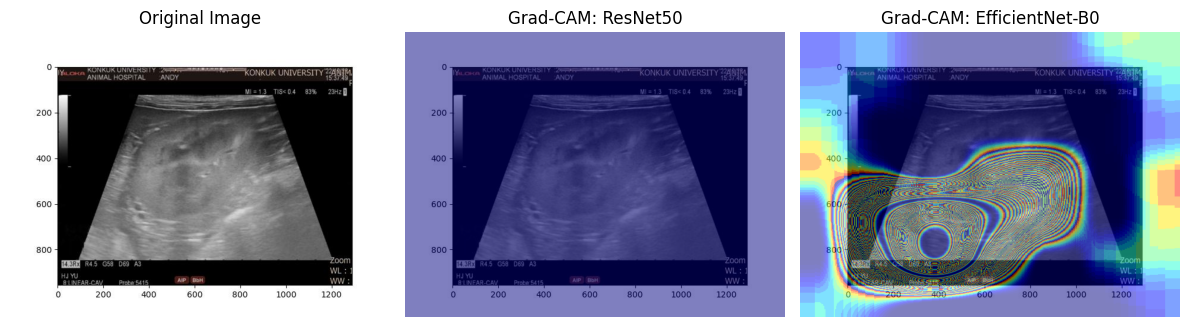

In [ ]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

#  Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Model 
model = HybridResNetEffNet(num_classes=5)
model.load_state_dict(torch.load("models\hybrid_model.pth", map_location=device))
model.eval().to(device)

# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load an image to interpret
image_path = "dataset\Stage4-4\\test\stage4-49-_png.rf.bfdd2dc2fbda32e14e64eea122305268.jpg"
input_tensor = transform(image).unsqueeze(0).to(device)

#  Choose the last conv layer from each backbone 
# name of layers can vary based on how you defined hybrid model
target_layer_resnet = model.resnet_features[-1]    # Example: resnet layer4
target_layer_effnet = model.effnet_features[-1]    # Example: efficientnet ConvHead

#Grad-CAM Setup
cam_resnet = GradCAM(model=model, target_layer=target_layer_resnet, input_shape=(3, 224, 224))
cam_effnet = GradCAM(model=model, target_layer=target_layer_effnet, input_shape=(3, 224, 224))

#  Forward Pass
out = model(input_tensor)
pred_class = out.argmax(dim=1).item()
print(f"Predicted Class: Stage{pred_class}")

# Grad-CAM for ResNet path
out_r = model(input_tensor)
activation_map_r = cam_resnet(class_idx=pred_class, scores=out_r)

# Grad-CAM for EfficientNet path (new forward pass)
out_e = model(input_tensor)
activation_map_e = cam_effnet(class_idx=pred_class, scores=out_e)

# Overlay Heatmaps 

from torchvision.transforms.functional import to_pil_image

#Case: image is a tensor to convert to PIL
if isinstance(image, torch.Tensor):
    image_pil = to_pil_image(image.cpu())
else:
    image_pil = image  # Already a PIL image


#Prepare CAMs
cam_r_tensor = activation_map_r[0]
cam_e_tensor = activation_map_e[0]

if cam_r_tensor.dim() == 3 and cam_r_tensor.shape[0] == 1:
    cam_r_tensor = cam_r_tensor.squeeze(0)
if cam_e_tensor.dim() == 3 and cam_e_tensor.shape[0] == 1:
    cam_e_tensor = cam_e_tensor.squeeze(0)

# Convert to PIL
cam_r_pil = to_pil_image(cam_r_tensor)
cam_e_pil = to_pil_image(cam_e_tensor)

# Overlay CAM on original image
resnet_map = overlay_mask(image_pil, cam_r_pil, alpha=0.5)
effnet_map = overlay_mask(image_pil, cam_e_pil, alpha=0.5)

# Plot Results
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(image)
ax[0].set_title("Original Image")

ax[1].imshow(resnet_map)
ax[1].set_title("Grad-CAM: ResNet50")

ax[2].imshow(effnet_map)
ax[2].set_title("Grad-CAM: EfficientNet-B0")

for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()
